<a href="https://colab.research.google.com/github/ManhattanCB01-nyc/CrashVehiclesDataPipeline/blob/main/finalcrashescode_fixed_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC Motor Vehicle Collisions — Data Pipeline (CB1 fix + BigQuery write)

Changes from the previous version:
1. **Fixed CB1 extraction** — the old code filtered by a hardcoded ZIP-code list (`specific_manhattan_zipcodes`). ZIP codes and Community Districts don't nest cleanly (e.g. ZIP 10038 is only ~66.5% Manhattan CD1, the rest is CD3; ZIP 10013 spills into SoHo and Little Italy). That's why blue dots were showing up outside the CB1 boundary on the map. This version does a real point-in-polygon spatial join against the official Community District boundary file and keeps only `BoroCD == 101` (Manhattan CD1).
2. **Added Google BigQuery write** using the same service-account auth pattern as `BigQuery.ipynb` (project `stable-liberty-426016-d2`, dataset `nyc_collisions_data`, table `cb1_crashes`), so it can be run unattended in the GitHub Actions workflow.


In [1]:
import os
try:
    import google.colab
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False
print(f"Running in Colab: {RUNNING_IN_COLAB}")


Running in Colab: True


## 1. Setup

In [2]:
# Install geospatial + BigQuery dependencies (Colab only needs this once per runtime)
!pip install geopandas shapely google-auth google-api-python-client pandas-gbq -q

import os
import time
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

# ── Google Drive mount (conditional on Colab environment) ────────────────────
if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    default_drive_path = "/content/drive/MyDrive/BigQueryDatasets/Collisions"
else:
    default_drive_path = "./data/Collisions"  # local / GitHub Actions runner

# ── Paths ───────────────────────────────────────────────────────────────────
DRIVE_PATH  = os.getenv("COLLISION_DRIVE_PATH", default_drive_path)
CSV_FILE    = os.path.join(DRIVE_PATH, "Collision_crashes.csv")
STATE_FILE  = os.path.join(DRIVE_PATH, "last_update.txt")
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── NYC Socrata API ─────────────────────────────────────────────────────────
BASE_URL  = os.getenv("SOCIODATA_BASE_URL", "https://data.cityofnewyork.us/resource/h9gi-nx95.csv")
PAGE_SIZE = 50_000

# ── NYC bounding box (used throughout for coord validation) ─────────────────
NYC_LAT = (40.49, 40.92)
NYC_LON = (-74.26, -73.70)

print("Setup complete.")


Mounted at /content/drive
Setup complete.


## 2. Download from Socrata API

In [3]:
import datetime

if os.path.exists(STATE_FILE):
    with open(STATE_FILE) as f:
        start_date_str = f.read().strip()
    try:
        start_datetime = datetime.datetime.fromisoformat(start_date_str)
        if start_datetime > datetime.datetime.now():
            print(f"Warning: Checkpoint {start_date_str} is in the future. Resetting.")
            start_date_for_download = "2018-01-01"
        else:
            # Socrata crash_date is DATE not DATETIME — use date-only format
            start_date_for_download = start_datetime.strftime("%Y-%m-%d")
            print(f"Incremental update from {start_date_for_download}")
    except ValueError:
        print(f"Warning: Invalid checkpoint '{start_date_str}'. Resetting.")
        start_date_for_download = "2018-01-01"
else:
    start_date_for_download = "2018-01-01"
    print(f"First run — downloading everything since {start_date_for_download}")

def download_data(start_date_param):
    chunks = []
    offset = 0
    while True:
        url = (
            f"{BASE_URL}"
            f"?$where=crash_date>='{start_date_param}'"
            f"&$limit={PAGE_SIZE}"
            f"&$offset={offset}"
            f"&$order=crash_date%20ASC"
        )
        print(f"  offset {offset:,} ...", end=" ")
        try:
            chunk = pd.read_csv(url)
        except Exception as e:
            print(f"FAILED — {e}")
            break
        if chunk.empty:
            print("done.")
            break
        print(f"{len(chunk):,} rows")
        chunks.append(chunk)
        offset += PAGE_SIZE
    return chunks

chunks = download_data(start_date_for_download)
if not chunks and start_date_for_download != "2018-01-01":
    print(f"No data with start_date='{start_date_for_download}'. Retrying from 2018-01-01.")
    start_date_for_download = "2018-01-01"
    chunks = download_data(start_date_for_download)
if not chunks:
    raise RuntimeError("No data downloaded — check the API URL / date filter.")

new_data = pd.concat(chunks, ignore_index=True)
new_data["collision_id"] = pd.to_numeric(new_data["collision_id"], errors="coerce").astype("Int64")
print(f"\nDownloaded {len(new_data):,} rows total.")


Incremental update from 2026-06-11
  offset 0 ... 12 rows
  offset 50,000 ... done.

Downloaded 12 rows total.


## 3. Merge with existing data & deduplicate

In [4]:
EXPECTED_COLS = new_data.columns.tolist()

def normalise_columns(df: pd.DataFrame, expected: list) -> pd.DataFrame:
    """Lowercase + underscore column names, drop extras, add missing."""
    df = df.copy()
    df.columns = df.columns.str.lower().str.replace(" ", "_", regex=False)
    df = df.loc[:, ~df.columns.duplicated()]
    df = df.drop(columns=[c for c in df.columns if c not in expected], errors="ignore")
    for col in expected:
        if col not in df.columns:
            df[col] = pd.NA
    return df[expected]

if os.path.exists(CSV_FILE):
    existing = normalise_columns(pd.read_csv(CSV_FILE, low_memory=False), EXPECTED_COLS)
    existing["collision_id"] = pd.to_numeric(existing["collision_id"], errors="coerce").astype("Int64")
    print(f"Loaded {len(existing):,} existing rows from Drive.")
else:
    existing = pd.DataFrame(columns=EXPECTED_COLS)
    print("No existing file found — starting fresh.")

combined = pd.concat([existing, new_data], ignore_index=True)
before = len(combined)
combined = combined.drop_duplicates(subset=["collision_id"])
print(f"Removed {before - len(combined):,} duplicate rows — {len(combined):,} remain.")


Loaded 1,079,301 existing rows from Drive.
Removed 12 duplicate rows — 1,079,301 remain.


## 4. Geospatial Enrichment

Fills missing `borough` and `zip_code` via three methods in order:
1. **Polygon sjoin** — point-in-polygon against official NYC boundary files
2. **Street-average lookup** — fallback using average coords of known streets
3. **Nearest-neighbour join** — final fallback for points near polygon edges


In [5]:
import requests, io
import geopandas as gpd

def fetch_geojson(url: str, label: str) -> gpd.GeoDataFrame:
    """Download a GeoJSON URL into a GeoDataFrame without touching the filesystem."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    if len(resp.content) < 500:
        raise RuntimeError(f"{label}: response too small ({len(resp.content)} bytes) — likely an error page")
    gdf = gpd.read_file(io.BytesIO(resp.content))
    print(f"  {label}: {len(gdf)} polygons OK")
    return gdf

# Reliable GitHub raw sources
BOR_URL = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/boroughs.geojson"
ZIP_URL = "https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson"

borough_gdf = fetch_geojson(BOR_URL, "Boroughs").to_crs(epsg=4326)
zip_gdf     = fetch_geojson(ZIP_URL, "ZIP codes").to_crs(epsg=4326)

boro_col = next((c for c in borough_gdf.columns
                  if c.lower() in ["boroname", "borough", "name", "boro_name"]), None)
if boro_col and boro_col != "BoroName":
    borough_gdf = borough_gdf.rename(columns={boro_col: "BoroName"})

zip_col = next((c for c in zip_gdf.columns
                  if c.lower() in ["postalcode", "zipcode", "zip", "modzcta",
                                    "zip_code", "zcta5ce10", "zipst"]), None)
if zip_col and zip_col != "MODZCTA":
    zip_gdf = zip_gdf.rename(columns={zip_col: "MODZCTA"})

borough_gdf = borough_gdf[["BoroName", "geometry"]]
zip_gdf     = zip_gdf[["MODZCTA", "geometry"]]


  Boroughs: 5 polygons OK
  ZIP codes: 262 polygons OK


In [6]:
def run_sjoin(df: pd.DataFrame,
               borough_gdf: gpd.GeoDataFrame,
               zip_gdf: gpd.GeoDataFrame,
               predicate: str = "within") -> None:
    """Point-in-polygon spatial join. Writes results into global `combined`."""
    if df.empty:
        return
    gdf = gpd.GeoDataFrame(
        df[[]],
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    )
    b_join = gpd.sjoin(gdf, borough_gdf, how="left", predicate=predicate)
    b_join = b_join.groupby(level=0).first()
    mask_b = combined.loc[b_join.index, "borough"].isna() | \
             (combined.loc[b_join.index, "borough"] == "UNKNOWN")
    combined.loc[b_join.index[mask_b], "borough"] = \
        b_join.loc[mask_b, "BoroName"].str.upper()

    z_join = gpd.sjoin(gdf, zip_gdf, how="left", predicate=predicate)
    z_join = z_join.groupby(level=0).first()
    mask_z = combined.loc[z_join.index, "zip_code"].isna() | \
             (combined.loc[z_join.index, "zip_code"] == 0)
    combined.loc[z_join.index[mask_z], "zip_code"] = \
        z_join.loc[mask_z, "MODZCTA"].astype(float)


def run_nearest(df: pd.DataFrame,
                 borough_gdf: gpd.GeoDataFrame,
                 zip_gdf: gpd.GeoDataFrame) -> None:
    """Nearest-neighbour fallback. Only fills rows that are still missing."""
    if df.empty:
        return
    gdf_proj = gpd.GeoDataFrame(
        df[[]],
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    ).to_crs(epsg=2263)

    b_proj = borough_gdf.to_crs(epsg=2263)
    z_proj = zip_gdf.to_crs(epsg=2263)

    b_near = gpd.sjoin_nearest(gdf_proj, b_proj[["BoroName", "geometry"]],
                                how="left").groupby(level=0).first()
    z_near = gpd.sjoin_nearest(gdf_proj, z_proj[["MODZCTA", "geometry"]],
                                how="left").groupby(level=0).first()

    mask_b = combined.loc[b_near.index, "borough"].isna() | \
             (combined.loc[b_near.index, "borough"] == "UNKNOWN")
    mask_z = combined.loc[z_near.index, "zip_code"].isna() | \
             (combined.loc[z_near.index, "zip_code"] == 0)

    combined.loc[b_near.index[mask_b], "borough"] = \
        b_near.loc[mask_b, "BoroName"].str.upper()
    combined.loc[z_near.index[mask_z], "zip_code"] = \
        z_near.loc[mask_z, "MODZCTA"].astype(float)

# Step 0: normalise types & null out garbage coordinates
combined["borough"] = combined["borough"].replace(["None", "none", "NaN", "nan", "<NA>"], np.nan)
combined["zip_code"] = pd.to_numeric(combined["zip_code"], errors="coerce")
bad_coords = (
    combined["latitude"].notna() &
    (~combined["latitude"].between(*NYC_LAT) |
     ~combined["longitude"].between(*NYC_LON))
)
combined.loc[bad_coords, ["latitude", "longitude", "location"]] = np.nan
print(f"Nulled {bad_coords.sum():,} out-of-bounds coordinate rows.")

def missing_report():
    b = combined["borough"].isna().sum()
    z = combined["zip_code"].isna().sum()
    print(f"  borough missing: {b:,} | zip_code missing: {z:,}")

# Step 1: polygon sjoin
needs_enrichment = (
    (combined["borough"].isna() | combined["zip_code"].isna()) &
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
)
run_sjoin(combined[needs_enrichment], borough_gdf, zip_gdf, predicate="within")
missing_report()

# Step 2: street-average fallback for rows with no coords at all
valid = combined[
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
].copy()
valid["street_key"] = valid["on_street_name"].astype(str).str.strip().str.upper()
street_map = valid.groupby("street_key")[["latitude", "longitude"]].mean()

no_coords = combined["latitude"].isna() & combined["on_street_name"].notna()
combined["street_key"] = combined["on_street_name"].astype(str).str.strip().str.upper()
combined.loc[no_coords, "latitude"]  = combined.loc[no_coords, "street_key"].map(street_map["latitude"])
combined.loc[no_coords, "longitude"] = combined.loc[no_coords, "street_key"].map(street_map["longitude"])
filled = no_coords & combined["latitude"].notna()
combined.loc[filled, "location"] = combined.loc[filled].apply(
    lambda r: f"({r['latitude']:.6f}, {r['longitude']:.6f})", axis=1
)
combined.drop(columns=["street_key"], inplace=True, errors="ignore")

needs_enrichment2 = (
    (combined["borough"].isna() | combined["zip_code"].isna()) &
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
)
run_sjoin(combined[needs_enrichment2], borough_gdf, zip_gdf, predicate="within")
missing_report()

# Step 3: nearest-neighbour fallback for anything still missing
still_missing = (
    (combined["borough"].isna() | combined["zip_code"].isna()) &
    combined["latitude"].between(*NYC_LAT) &
    combined["longitude"].between(*NYC_LON)
)
run_nearest(combined[still_missing], borough_gdf, zip_gdf)
missing_report()

# Step 4: sentinel-fill unresolvable rows, then drop them (as before)
combined["borough"]  = combined["borough"].fillna("UNKNOWN")
combined["zip_code"] = combined["zip_code"].fillna(0)
before_drop = len(combined)
combined = combined[~((combined["borough"] == "UNKNOWN") & (combined["zip_code"] == 0))]
print(f"Dropped {before_drop - len(combined):,} rows with UNKNOWN borough and 0 zip code.")


Nulled 0 out-of-bounds coordinate rows.
  borough missing: 0 | zip_code missing: 0
  borough missing: 0 | zip_code missing: 0
  borough missing: 0 | zip_code missing: 0
Dropped 0 rows with UNKNOWN borough and 0 zip code.


## 5. Final Cleanup & Save (full NYC dataset)

In [7]:
combined = combined.dropna(subset=["collision_id"])
combined.to_csv(CSV_FILE, index=False)
print(f"Saved to:\n  {CSV_FILE}")

latest = pd.to_datetime(new_data["crash_date"]).max()
with open(STATE_FILE, "w") as f:
    f.write(latest.strftime("%Y-%m-%d"))
print(f"Checkpoint updated to: {latest.strftime('%Y-%m-%d')}")
print(f"Final dataset: {len(combined):,} rows x {len(combined.columns)} columns.")


Saved to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes.csv
Checkpoint updated to: 2026-06-11
Final dataset: 1,079,301 rows x 29 columns.


## 6. Extract Manhattan Community District 1 (FIXED)

**Old behaviour (removed):** filtered `zip_code.isin([10004, 10005, 10006, 10007, 10038, 10280, 10282, 10013, 10002, 10281])`. ZIP-code polygons do not line up with Community District polygons, so this pulled in crashes from parts of ZIP 10038 that are actually in Manhattan CD3, and parts of 10013/10002 that are in SoHo, Little Italy, and the East Village — which is exactly the scatter you saw outside the CB1 boundary line on the map.

**New behaviour:** point-in-polygon spatial join against the official Community District boundary file, keeping only `BoroCD == 101` (Manhattan Community District 1). Every point plotted is now guaranteed to sit inside the actual CB1 polygon, not just inside a ZIP code that mostly overlaps it.


In [8]:
CD_URL = "https://raw.githubusercontent.com/dwillis/nyc-maps/master/community_districts.geojson"
cd_gdf = fetch_geojson(CD_URL, "Community Districts").to_crs(epsg=4326)

# Find the column holding the BoroCD code (varies by source vintage)
cd_col = next((c for c in cd_gdf.columns
               if c.lower() in ["borocd", "boro_cd", "boro_cd_id", "cd_id"]), None)
if cd_col is None:
    raise RuntimeError(f"Could not find a BoroCD-style column in: {cd_gdf.columns.tolist()}")
cd_gdf[cd_col] = pd.to_numeric(cd_gdf[cd_col], errors="coerce")

CB1_CODE = 101  # Manhattan Community District 1 (borough code 1 + district 01)
cb1_polygon = cd_gdf[cd_gdf[cd_col] == CB1_CODE][["geometry"]]
if cb1_polygon.empty:
    raise RuntimeError(f"No polygon found for BoroCD == {CB1_CODE} — check the source file's column values.")
print(f"CB1 polygon loaded ({len(cb1_polygon)} feature(s)).")

# Only points with valid, real (non-street-average-guessed) coordinates go into the spatial join
manhattan = combined[combined["borough"] == "MANHATTAN"].copy()
has_coords = manhattan["latitude"].between(*NYC_LAT) & manhattan["longitude"].between(*NYC_LON)
pts = gpd.GeoDataFrame(
    manhattan[has_coords],
    geometry=gpd.points_from_xy(manhattan.loc[has_coords, "longitude"],
                                 manhattan.loc[has_coords, "latitude"]),
    crs="EPSG:4326",
)

cb1_join = gpd.sjoin(pts, cb1_polygon, how="inner", predicate="within")
cb1_crashes = combined.loc[cb1_join.index].copy()
cb1_crashes["community_district"] = "MN01"

print(f"Rows in Manhattan (any coords): {len(manhattan):,}")
print(f"Rows with usable coordinates:   {has_coords.sum():,}")
print(f"Rows actually inside CB1 polygon: {len(cb1_crashes):,}")

CB1_CSV_FILE = os.path.join(DRIVE_PATH, "Collision_crashes_CB1.csv")
cb1_crashes.to_csv(CB1_CSV_FILE, index=False)
print(f"Saved CB1-only crash data to:\n  {CB1_CSV_FILE}")
display(cb1_crashes.head())


  Community Districts: 71 polygons OK
CB1 polygon loaded (1 feature(s)).
Rows in Manhattan (any coords): 195,573
Rows with usable coordinates:   192,847
Rows actually inside CB1 polygon: 10,537
Saved CB1-only crash data to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes_CB1.csv


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,...,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code1,vehicle_type_code2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,community_district
100,2018-01-02,18:45,MANHATTAN,10013.0,40.718430,-74.000534,"(40.71843, -74.000534)",CANAL STREET,LAFAYETTE STREET,NaN,...,NaN,NaN,NaN,4061222,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN,MN01
161,2018-01-02,6:03,MANHATTAN,10038.0,40.707478,-74.000440,"(40.707478, -74.00044)",FDR DRIVE,NaN,NaN,...,NaN,NaN,NaN,3820842,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN,MN01
170,2018-01-02,17:05,MANHATTAN,10006.0,40.709496,-74.013900,"(40.709496, -74.0139)",ALBANY STREET,WASHINGTON STREET,NaN,...,NaN,NaN,NaN,3822067,Station Wagon/Sport Utility Vehicle,Taxi,NaN,NaN,NaN,MN01
227,2018-01-02,6:36,MANHATTAN,10005.0,40.705010,-74.007150,"(40.70501, -74.00715)",NaN,NaN,100 WALL STREET,...,NaN,NaN,NaN,3818948,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,MN01
292,2018-01-02,22:40,MANHATTAN,10038.0,40.708790,-74.000860,"(40.70879, -74.00086)",DOVER STREET,NaN,NaN,...,NaN,NaN,NaN,3821354,Taxi,Sedan,NaN,NaN,NaN,MN01


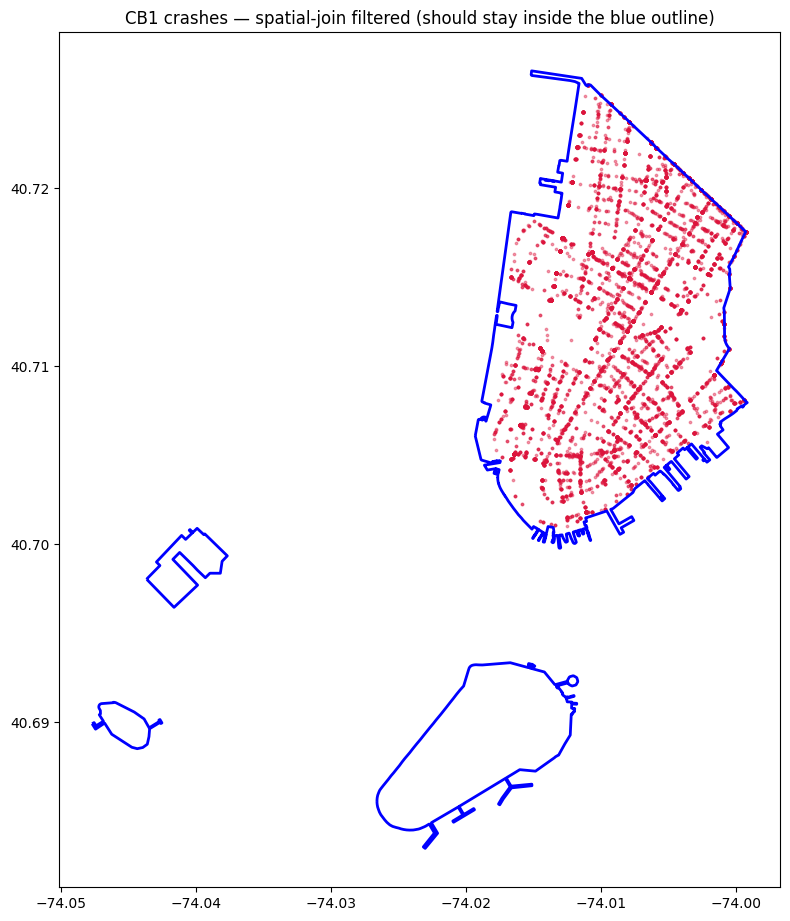

In [9]:
# Sanity-check map: every dot here should now sit inside the CB1 outline
fig, ax = plt.subplots(figsize=(8, 10))
cb1_polygon.boundary.plot(ax=ax, color="blue", linewidth=2)
gpd.GeoDataFrame(
    cb1_crashes,
    geometry=gpd.points_from_xy(cb1_crashes["longitude"], cb1_crashes["latitude"]),
    crs="EPSG:4326",
).plot(ax=ax, markersize=3, alpha=0.4, color="crimson")
ax.set_title("CB1 crashes — spatial-join filtered (should stay inside the blue outline)")
plt.tight_layout()
plt.show()


## 7. Download Vehicles & Person data (CB1 only)

Same two supplementary NYC Open Data tables from the original notebook — `Motor_Vehicle_Collisions_Vehicles` and `Motor_Vehicle_Collisions_Person` — but now filtered down to only the `collision_id`s that survived the CB1 spatial join, instead of the old ZIP-list filter. This keeps the join scoped to the same, correctly-bounded set of crashes.


In [10]:
VEHICLES_URL = os.getenv("VEHICLES_DATA_URL",
    "https://data.cityofnewyork.us/api/views/bm4k-52h4/rows.csv?accessType=DOWNLOAD")
VEHICLES_CSV_FILE = os.path.join(DRIVE_PATH, os.getenv("VEHICLES_DATA_FILE", "Motor_Vehicle_Collisions_Vehicles.csv"))

PERSON_URL = os.getenv("PERSON_DATA_URL",
    "https://data.cityofnewyork.us/api/views/f55k-p6yu/rows.csv?accessType=DOWNLOAD")
PERSON_CSV_FILE = os.path.join(DRIVE_PATH, os.getenv("PERSON_DATA_FILE", "Motor_Vehicle_Collisions_Person.csv"))

cb1_collision_ids = set(cb1_crashes["collision_id"].dropna().astype("int64"))
print(f"CB1 collision IDs to match against: {len(cb1_collision_ids):,}")

def download_and_filter(url: str, out_path: str, label: str) -> pd.DataFrame:
    """Download the full Socrata CSV once, cache it locally, then filter to CB1 collision_ids.
    Re-uses the cached file on subsequent runs unless FORCE_REDOWNLOAD=1 is set."""
    force = os.getenv("FORCE_REDOWNLOAD", "0") == "1"
    if force or not os.path.exists(out_path):
        print(f"Downloading {label} data ...")
        !wget -q -O {out_path} {url}
        print(f"  saved to {out_path}")
    else:
        print(f"Using cached {label} file at {out_path}")

    df = pd.read_csv(out_path, low_memory=False)
    df.columns = df.columns.str.lower()
    df["collision_id"] = pd.to_numeric(df["collision_id"], errors="coerce")
    filtered = df[df["collision_id"].isin(cb1_collision_ids)].copy()
    print(f"  {label}: {len(df):,} rows total -> {len(filtered):,} rows in CB1")
    return filtered

vehicles_cb1 = download_and_filter(VEHICLES_URL, VEHICLES_CSV_FILE, "Vehicles")
person_cb1   = download_and_filter(PERSON_URL, PERSON_CSV_FILE, "Person")

display(vehicles_cb1.head(3))
display(person_cb1.head(3))


CB1 collision IDs to match against: 10,537
Using cached Vehicles file at /content/drive/MyDrive/BigQueryDatasets/Collisions/Motor_Vehicle_Collisions_Vehicles.csv
  Vehicles: 4,551,002 rows total -> 20,110 rows in CB1
Using cached Person file at /content/drive/MyDrive/BigQueryDatasets/Collisions/Motor_Vehicle_Collisions_Person.csv
  Person: 5,984,110 rows total -> 36,362 rows in CB1


,unique_id,collision_id,crash_date,crash_time,vehicle_id,state_registration,vehicle_type,vehicle_make,vehicle_model,vehicle_year,...,pre_crash,point_of_impact,vehicle_damage,vehicle_damage_1,vehicle_damage_2,vehicle_damage_3,public_property_damage,public_property_damage_type,contributing_factor_1,contributing_factor_2
14,19694316,4322767,06/06/2020,18:30,fdc195a7-8127-4c00-834d-bac78b0cf88e,NaN,Bike,NaN,NaN,NaN,...,Going Straight Ahead,Center Front End,No Damage,No Damage,No Damage,No Damage,N,NaN,Traffic Control Disregarded,Unspecified
42187,19694313,4322678,05/26/2020,19:50,8cdd6bbe-bfcf-45ec-afed-d0bcc3af656f,NY,Sedan,JEEP -CAR/SUV,NaN,2020.0,...,Going Straight Ahead,Left Front Quarter Panel,Left Front Quarter Panel,NaN,NaN,NaN,N,NaN,Unspecified,Unspecified
47339,20612589,4707476,03/05/2024,14:00,95572e89-04c1-4943-aea4-4c0aa7f665a6,NJ,Sedan,TESL -CAR/SUV,NaN,2023.0,...,Parked,Right Front Bumper,Right Front Bumper,No Damage,No Damage,No Damage,N,NaN,Following Too Closely,Unspecified


,unique_id,collision_id,crash_date,crash_time,person_id,person_type,person_injury,vehicle_id,person_age,ejection,...,bodily_injury,position_in_vehicle,safety_equipment,ped_location,ped_action,complaint,ped_role,contributing_factor_1,contributing_factor_2,person_sex
24,10253825,4230931,10/25/2019,7:25,96cc826f-3b86-48e2-a925-2a032e03f4b3,Occupant,Unspecified,19143454.0,30.0,Not Ejected,...,Does Not Apply,"Left rear passenger, or rear passenger on a bi...",NaN,NaN,NaN,Does Not Apply,Passenger,NaN,NaN,F
28,10253863,4230926,10/26/2019,23:29,2d6d3318-7123-4a76-86ea-3ba68e076e0a,Occupant,Unspecified,19143471.0,37.0,Not Ejected,...,Does Not Apply,Driver,Lap Belt & Harness,NaN,NaN,Does Not Apply,Driver,NaN,NaN,M
35,10252810,4231118,10/23/2019,12:52,a2f35efd-c95e-4718-8c91-ca002a1109a0,Occupant,Unspecified,19142938.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Registrant,NaN,NaN,U


## 8. Aggregate Vehicles & Person data, join onto CB1 crashes

In [11]:
def join_unique(series):
    vals = series.dropna().astype(str).str.strip()
    vals = vals[vals.str.lower() != "nan"]
    unique_vals = vals.unique()
    return "|".join(unique_vals) if len(unique_vals) > 0 else None

# ── Vehicles aggregation ──────────────────────────────────────────────────
veh_agg = vehicles_cb1.groupby("collision_id").agg(
    total_vehicles         = ("vehicle_id", "count"),
    vehicle_types           = ("vehicle_type", join_unique),
    vehicle_makes           = ("vehicle_make", join_unique),
    travel_directions       = ("travel_direction", join_unique),
    any_unlicensed_driver   = ("driver_license_status",
        lambda s: s.str.upper().str.contains("UNLICENSED|REVOKED|SUSPENDED", na=False).any()),
).reset_index()

cf_cols_veh = [c for c in vehicles_cb1.columns if c.startswith("contributing_factor")]
vehicles_cb1["_any_alcohol"] = vehicles_cb1[cf_cols_veh].apply(
    lambda row: row.str.upper().str.contains("ALCOHOL", na=False).any(), axis=1
)
v_agg_alcohol = (
    vehicles_cb1.groupby("collision_id")["_any_alcohol"]
    .any().reset_index()
    .rename(columns={"_any_alcohol": "any_alcohol_vehicle"})
)
veh_agg = veh_agg.merge(v_agg_alcohol, on="collision_id", how="left")
print(f"Vehicles aggregated: {len(veh_agg):,} unique CB1 collisions")

# ── Person aggregation ────────────────────────────────────────────────────
person_cb1["person_age"] = pd.to_numeric(person_cb1["person_age"], errors="coerce")
person_cb1.loc[~person_cb1["person_age"].between(0, 120), "person_age"] = np.nan

person_cb1["_is_occupant"]   = person_cb1["person_type"].str.upper().str.contains("OCCUPANT", na=False)
person_cb1["_is_pedestrian"] = person_cb1["person_type"].str.upper().str.contains("PEDESTRIAN", na=False)
person_cb1["_is_cyclist"]    = person_cb1["person_type"].str.upper().str.contains("BICYCLIST", na=False)
person_cb1["_killed"]        = person_cb1["person_injury"].str.upper().str.contains("KILLED", na=False)
person_cb1["_injured"]       = person_cb1["person_injury"].str.upper().str.contains("INJURED", na=False)

def sex_breakdown(series):
    counts = series.dropna().str.upper().value_counts()
    counts = counts[counts.index.isin(["M", "F"])]
    return "|".join(f"{k}:{v}" for k, v in counts.items()) if not counts.empty else None

cf_cols_per = [c for c in person_cb1.columns if c.startswith("contributing_factor")]
person_cb1["_any_alcohol_per"] = person_cb1[cf_cols_per].apply(
    lambda row: row.str.upper().str.contains("ALCOHOL", na=False).any(), axis=1
)
person_cb1["_any_drug_per"] = person_cb1[cf_cols_per].apply(
    lambda row: row.str.upper().str.contains("DRUGS|DRUG", na=False).any(), axis=1
)

driver_ages = (
    person_cb1[person_cb1["_is_occupant"]]
    .groupby("collision_id")["person_age"]
    .mean().reset_index()
    .rename(columns={"person_age": "mean_driver_age"})
)

per_agg = person_cb1.groupby("collision_id").agg(
    total_persons_involved  = ("person_id", "count"),
    total_occupants          = ("_is_occupant", "sum"),
    total_pedestrians        = ("_is_pedestrian", "sum"),
    total_cyclists           = ("_is_cyclist", "sum"),
    any_killed                = ("_killed", "any"),
    any_injured                = ("_injured", "any"),
    driver_sex_breakdown       = ("person_sex", sex_breakdown),
    any_alcohol_person          = ("_any_alcohol_per", "any"),
    any_drug_person              = ("_any_drug_per", "any"),
).reset_index()
per_agg = per_agg.merge(driver_ages, on="collision_id", how="left")
print(f"Person data aggregated: {len(per_agg):,} unique CB1 collisions")

# ── Join everything onto the CB1 crash table ──────────────────────────────
cb1_crashes["collision_id"] = pd.to_numeric(cb1_crashes["collision_id"], errors="coerce").astype("Int64")
veh_agg["collision_id"]     = pd.to_numeric(veh_agg["collision_id"], errors="coerce").astype("Int64")
per_agg["collision_id"]     = pd.to_numeric(per_agg["collision_id"], errors="coerce").astype("Int64")

cb1_enriched = (
    cb1_crashes
    .merge(veh_agg, on="collision_id", how="left")
    .merge(per_agg, on="collision_id", how="left")
)

assert len(cb1_enriched) == len(cb1_crashes), \
    f"Row count changed during join: {len(cb1_enriched)} vs {len(cb1_crashes)}"

print(f"CB1 enriched table: {cb1_enriched.shape[0]:,} rows x {cb1_enriched.shape[1]} columns")

CB1_ENRICHED_CSV_FILE = os.path.join(DRIVE_PATH, "Collision_crashes_CB1_enriched.csv")
cb1_enriched.to_csv(CB1_ENRICHED_CSV_FILE, index=False)
print(f"Saved to:\n  {CB1_ENRICHED_CSV_FILE}")
display(cb1_enriched.head())


Vehicles aggregated: 10,536 unique CB1 collisions
Person data aggregated: 10,491 unique CB1 collisions
CB1 enriched table: 10,537 rows x 46 columns
Saved to:
  /content/drive/MyDrive/BigQueryDatasets/Collisions/Collision_crashes_CB1_enriched.csv


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,cross_street_name,...,total_persons_involved,total_occupants,total_pedestrians,total_cyclists,any_killed,any_injured,driver_sex_breakdown,any_alcohol_person,any_drug_person,mean_driver_age
0,2018-01-02,18:45,MANHATTAN,10013.0,40.718430,-74.000534,"(40.71843, -74.000534)",CANAL STREET,LAFAYETTE STREET,NaN,...,4.0,4.0,0.0,0.0,False,False,M:2|F:1,False,False,12.50
1,2018-01-02,6:03,MANHATTAN,10038.0,40.707478,-74.000440,"(40.707478, -74.00044)",FDR DRIVE,NaN,NaN,...,4.0,4.0,0.0,0.0,False,False,M:3|F:1,False,False,35.75
2,2018-01-02,17:05,MANHATTAN,10006.0,40.709496,-74.013900,"(40.709496, -74.0139)",ALBANY STREET,WASHINGTON STREET,NaN,...,4.0,4.0,0.0,0.0,False,False,M:2,False,False,15.00
3,2018-01-02,6:36,MANHATTAN,10005.0,40.705010,-74.007150,"(40.70501, -74.00715)",NaN,NaN,100 WALL STREET,...,4.0,4.0,0.0,0.0,False,False,F:2|M:2,False,False,37.00
4,2018-01-02,22:40,MANHATTAN,10038.0,40.708790,-74.000860,"(40.70879, -74.00086)",DOVER STREET,NaN,NaN,...,2.0,2.0,0.0,0.0,False,False,M:1,False,False,25.00


## 9. Write CB1 (vehicles + person enriched) data to BigQuery

Uses the same service-account authentication pattern as `BigQuery.ipynb`:
- **Colab**: key file read from the shared Drive location.
- **GitHub Actions / local**: key file written from the `SERVICE_ACCOUNT_JSON_KEY` secret to `service_account_key.json` in the working directory (the workflow below already does this — no manual step needed).

Destination: project `stable-liberty-426016-d2`, dataset **`nyc_collisions_data`**, table `cb1_crashes`.

This table is a full derived extract (crash + vehicle + person aggregates) recomputed from the whole historical dataset each run, so it's written with `if_exists='replace'` rather than append — that avoids duplicate rows piling up daily. Say the word if you'd rather append + dedupe by `collision_id` instead.


In [12]:
from google.oauth2 import service_account

# <<< BIGQUERY CONFIGURATION >>>
GOOGLE_CLOUD_PROJECT_ID = "stable-liberty-426016-d2"
BIGQUERY_TABLE_ID = "nyc_collisions_data.cb1_crashes"

# Dynamic path for the service account key (mirrors BigQuery.ipynb)
if RUNNING_IN_COLAB:
    SERVICE_ACCOUNT_KEY_FILE = "/content/drive/Shareddrives/311_Complaint_Data/service_account_key.json"
else:
    SERVICE_ACCOUNT_KEY_FILE = "service_account_key.json"

def upload_cb1_to_bigquery(df: pd.DataFrame) -> None:
    if df.empty:
        print("No CB1 rows to upload — skipping BigQuery write.")
        return
    try:
        creds = service_account.Credentials.from_service_account_file(
            SERVICE_ACCOUNT_KEY_FILE,
            scopes=["https://www.googleapis.com/auth/cloud-platform",
                    "https://www.googleapis.com/auth/drive"],
        )
        print("Authentication successful.")
    except Exception as e:
        print(f"FATAL: Authentication failed: {e}")
        return

    upload_df = df.copy()
    # BigQuery-friendly dtypes: object 'collision_id' Int64 -> plain int, dates -> string
    upload_df["collision_id"] = pd.to_numeric(upload_df["collision_id"], errors="coerce").astype("Int64")

    print(f"Uploading {len(upload_df):,} CB1 rows to "
          f"{GOOGLE_CLOUD_PROJECT_ID}.{BIGQUERY_TABLE_ID} ...")
    try:
        upload_df.to_gbq(
            destination_table=BIGQUERY_TABLE_ID,
            project_id=GOOGLE_CLOUD_PROJECT_ID,
            if_exists="replace",
            credentials=creds,
        )
        print("Successfully wrote CB1 crash data to BigQuery.")
    except Exception as e:
        print(f"FATAL: Failed to upload data to BigQuery: {e}")

upload_cb1_to_bigquery(cb1_enriched)


Authentication successful.
Uploading 10,537 CB1 rows to stable-liberty-426016-d2.nyc_collisions_data.cb1_crashes ...


/tmp/ipykernel_7157/1463885984.py:35: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  upload_df.to_gbq(
100%|██████████| 1/1 [00:00<00:00, 3775.25it/s]

Successfully wrote CB1 crash data to BigQuery.
